#Task 3: Vectorized Convolutional Forward Pass via im2col Transformation from Scratch
#Objective:
 Understand the mechanics of spatial feature extractors by implementing
vectorized convolutional layers optimized for high-performance matrix multiplications.
#Required Tech Stack:
 Pure NumPy, Python 3.10+, SciPy.
#Task Description:
 Students must implement a 2D convolutional layer supporting arbitrary
padding, strides, and input/output channels from scratch. They are required to write an
im2col matrix helper to reshape the input tensor into a unified 2D matrix, transforming
sliding window convolutions into a single dot-product operation (
)

Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

Create Multi-Channel Input

In [2]:
# Input Shape: (Channels, Height, Width)

C = 3
H = 8
W = 8

X = np.random.rand(C, H, W)

print("Input Shape:", X.shape)

Input Shape: (3, 8, 8)


Padding Function

In [3]:
def pad_input(X, padding):

    return np.pad(
        X,
        ((0,0),(padding,padding),(padding,padding)),
        mode='constant'
    )

im2col Implementation

In [4]:
def im2col(X, kernel_size, stride=1, padding=0):

    C,H,W = X.shape

    X = pad_input(X,padding)

    out_h = (H + 2*padding - kernel_size)//stride + 1
    out_w = (W + 2*padding - kernel_size)//stride + 1

    cols = []

    for y in range(out_h):
        for x in range(out_w):

            patch = X[
                :,
                y*stride:y*stride+kernel_size,
                x*stride:x*stride+kernel_size
            ]

            cols.append(patch.flatten())

    return np.array(cols)

Initialize Filters

In [5]:
num_filters = 4
kernel_size = 3

filters = np.random.randn(
    num_filters,
    C,
    kernel_size,
    kernel_size
)

bias = np.zeros(num_filters)

print("Filter Shape:", filters.shape)

Filter Shape: (4, 3, 3, 3)


Vectorized Convolution

In [6]:
def conv2d_im2col(X, filters, bias, stride=1, padding=1):

    kernel_size = filters.shape[2]

    cols = im2col(
        X,
        kernel_size,
        stride,
        padding
    )

    filter_matrix = filters.reshape(
        filters.shape[0],
        -1
    )

    output = np.dot(
        cols,
        filter_matrix.T
    )

    output += bias

    H = X.shape[1]

    out_h = (H + 2*padding - kernel_size)//stride + 1

    out_w = (X.shape[2] + 2*padding - kernel_size)//stride + 1

    output = output.reshape(
        out_h,
        out_w,
        filters.shape[0]
    )

    output = output.transpose(2,0,1)

    return output

Perform Convolution

In [7]:
feature_maps = conv2d_im2col(
    X,
    filters,
    bias,
    stride=1,
    padding=1
)

print(feature_maps.shape)

(4, 8, 8)


Visualize Feature Maps

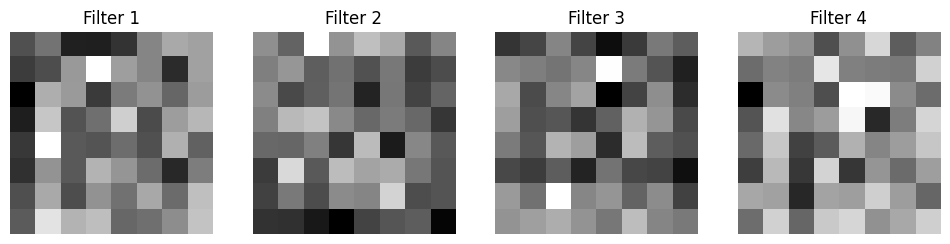

In [8]:
plt.figure(figsize=(12,3))

for i in range(feature_maps.shape[0]):

    plt.subplot(1,4,i+1)

    plt.imshow(
        feature_maps[i],
        cmap='gray'
    )

    plt.title(f"Filter {i+1}")

    plt.axis('off')

plt.show()

Test Different Padding

In [9]:
for p in [0,1,2]:

    out = conv2d_im2col(
        X,
        filters,
        bias,
        stride=1,
        padding=p
    )

    print(f"Padding {p} -> {out.shape}")

Padding 0 -> (4, 6, 6)
Padding 1 -> (4, 8, 8)
Padding 2 -> (4, 10, 10)


Test Different Strides

In [10]:
for s in [1,2]:

    out = conv2d_im2col(
        X,
        filters,
        bias,
        stride=s,
        padding=1
    )

    print(f"Stride {s} -> {out.shape}")

Stride 1 -> (4, 8, 8)
Stride 2 -> (4, 4, 4)


Verify Against a Naive Convolution

In [11]:
def naive_conv2d(X, filters, bias, stride=1, padding=1):
    C, H, W = X.shape
    F, _, K, _ = filters.shape

    X_pad = pad_input(X, padding)

    out_h = (H + 2 * padding - K) // stride + 1
    out_w = (W + 2 * padding - K) // stride + 1

    output = np.zeros((F, out_h, out_w))

    for f in range(F):
        for i in range(out_h):
            for j in range(out_w):
                region = X_pad[:, i*stride:i*stride+K, j*stride:j*stride+K]
                output[f, i, j] = np.sum(region * filters[f]) + bias[f]

    return output

naive_output = naive_conv2d(X, filters, bias)
im2col_output = conv2d_im2col(X, filters, bias)

print("Outputs equal:", np.allclose(naive_output, im2col_output))

Outputs equal: True
